## 1. Utilize Machine Learning - based training recommendation for optimizing marathon performance

Traditional one-size-fits-all approaches increasingly demonstrate inadequate accommodation of substantial inter-individual differences in physiological responses, recovery capacity, and adaptation rates among runners.

Contemporary training prescription faces the fundamental challenge of reconciling standardized protocols with the inherent biological variability that characterizes human athletic performance, particularly in endurance sports where
training adaptations unfold over extended periods and involve complex physiological systems.

The integration of machine learning (ML) into training recommendation systems offers a promising avenue for addressing these challenges by leveraging data-driven insights to tailor training regimens to individual athletes.

## 2. Training Trajectory Similarity — Dynamic Time Warping
Compares the weekly [km, avg HR] fingerprint of the current Amsterdam block against the same first N weeks of each completed marathon to find the closest match.

In [29]:
# Requires: pip install fastdtw

import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw
import os
from dotenv import load_dotenv
load_dotenv()

host     = os.getenv("SUPABASE_HOST")
user_db  = os.getenv("SUPABASE_USER")
password = os.getenv("SUPABASE_PASSWORD")
engine   = create_engine(f"postgresql+psycopg2://{user_db}:{password}@{host}:6543/postgres")

df_ml = pd.read_sql("""
    SELECT a.start_date, a.activity_type, a.activity_name,
           a.distance, a.duration, a.elevation,
           a.avg_speed, a.avg_heartrate, a.suffer_score
    FROM activities a
    JOIN athletes ath ON a.athlete_id = ath.id
    ORDER BY a.start_date ASC
""", engine)
df_ml["start_date"] = pd.to_datetime(df_ml["start_date"])
runs_ml = df_ml[df_ml["activity_type"] == "Run"].dropna(subset=["distance"]).copy()

EXCLUDE = r"interval|sprint|tempo|fartlek|race|hill repeat|track workout"

def weekly_features(runs, start, end=None, n_weeks=None):
    """Returns array of shape (weeks, 2): [weekly_km, avg_hr_easy] per week."""
    mask = runs["start_date"] >= pd.Timestamp(start)
    if end:
        mask &= runs["start_date"] < pd.Timestamp(end)
    b = runs[mask].copy()
    if len(b) == 0:
        return np.empty((0, 2))
    b["week"] = (b["start_date"] - pd.Timestamp(start)).dt.days // 7
    km_w  = b.groupby("week")["distance"].sum()
    easy  = b[~b["activity_name"].str.contains(EXCLUDE, case=False, na=False)]
    hr_w  = easy.dropna(subset=["avg_heartrate"]).groupby("week")["avg_heartrate"].mean()
    max_w = int(km_w.index.max()) + 1
    if n_weeks:
        max_w = min(max_w, n_weeks)
    return np.array([[km_w.get(w, 0.0), hr_w.get(w, np.nan)] for w in range(max_w)], dtype=float)

# Extract features for each block
feat_current = weekly_features(runs_ml, "2026-06-15")
n = len(feat_current)
feat_1 = weekly_features(runs_ml, "2024-06-01", "2024-10-13", n_weeks=n)
feat_2 = weekly_features(runs_ml, "2025-10-20", "2026-05-10",  n_weeks=n)

# Normalize features using global mean/std so km and HR contribute equally
all_data = np.vstack([feat_1, feat_2, feat_current])
for col in range(2):
    mu  = np.nanmean(all_data[:, col])
    sig = np.nanstd(all_data[:, col]) or 1.0
    for f in [feat_1, feat_2, feat_current]:
        f[np.isnan(f[:, col]), col] = mu   # fill NaN HR with global mean
        f[:, col] = (f[:, col] - mu) / sig

# DTW similarity
dist_1, _ = fastdtw(feat_current, feat_1, dist=euclidean)
dist_2, _ = fastdtw(feat_current, feat_2, dist=euclidean)

closer = "Copenhagen 2026" if dist_2 < dist_1 else "Eindhoven 2024"
other  = "Eindhoven 2024"  if dist_2 < dist_1 else "Copenhagen 2026"

print(f"Weeks of Amsterdam data compared: {n}")
print(f"DTW distance — Eindhoven 2024:  {dist_1:.2f}")
print(f"DTW distance — Copenhagen 2026: {dist_2:.2f}")
print(f"\nAmsterdam is tracking closest to: {closer}")
print(f"({min(dist_1,dist_2):.2f} vs {max(dist_1,dist_2):.2f} for {other})")

Weeks of Amsterdam data compared: 9
DTW distance — Eindhoven 2024:  20.29
DTW distance — Copenhagen 2026: 14.53

Amsterdam is tracking closest to: Copenhagen 2026
(14.53 vs 20.29 for Eindhoven 2024)


## 3. Acute:Chronic Workload Ratio (ACWR) — Injury Risk Monitor

The ACWR compares the **acute** workload (last 7 days) against the **chronic** workload (rolling 28-day average weekly load) to keep track of injury risk from load spikes.
A ratio between **0.8 – 1.3** is considered the "sweet spot" for adaptation without elevated injury risk.
Above **1.3** flags a spike; above **1.5** is considered high risk for injury.

E.g. for a runner with a chronic load of 50 km/week, an acute load of 65 km/week yields an ACWR of 1.3 (caution) indicating you trained more this week than you normally would, while 80 km/week yields 1.6 (high risk). Meanwhile, an ACWR below 0.8 indicates under-training, which may lead to loss of fitness and performance.

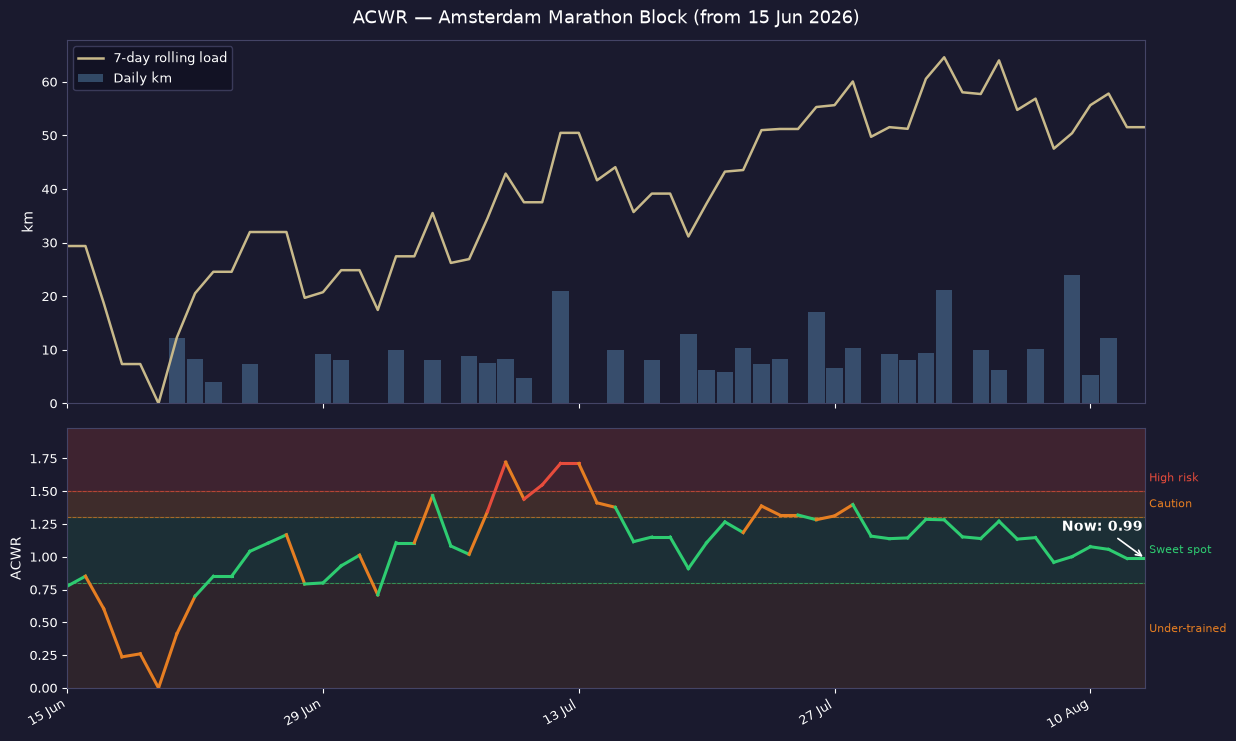

Acute load  (last 7 days):     51.5 km
Chronic load (avg weekly/28d): 52.2 km
Current ACWR:                  0.987  →  sweet spot ✓


In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

BLOCK_START    = pd.Timestamp("2026-06-15")
BASELINE_START = BLOCK_START - pd.Timedelta(weeks=4)   # 4-week warm-up for chronic baseline

# ── Build daily load from baseline (for rolling windows) ─────────────────────
baseline = runs_ml[runs_ml["start_date"] >= BASELINE_START].copy()
baseline["date"] = baseline["start_date"].dt.normalize()

daily = baseline.groupby("date")["distance"].sum().rename("km")
idx_full = pd.date_range(BASELINE_START, pd.Timestamp.today().normalize(), freq="D")
daily = daily.reindex(idx_full, fill_value=0.0)

acute   = daily.rolling(7,  min_periods=1).sum()
chronic = daily.rolling(28, min_periods=7).sum() / 4
acwr    = (acute / chronic).replace([np.inf, -np.inf], np.nan)

current_acwr    = acwr.dropna().iloc[-1] if acwr.dropna().size else np.nan
current_acute   = acute.iloc[-1]
current_chronic = chronic.iloc[-1]

# ── Trim to display window (from BLOCK_START) ─────────────────────────────────
plot_mask  = daily.index >= BLOCK_START
dates      = daily.index[plot_mask]
daily_plot = daily.values[plot_mask]
acute_plot = acute.values[plot_mask]
acwr_vals  = acwr.values[plot_mask]

# ── Plot ─────────────────────────────────────────────────────────────────────
BG      = "#1A1A2E"
CREAM   = "#C8B98A"
ACUTE_C = "#5B8DB8"
RISK_G  = "#2ECC71"
RISK_O  = "#E67E22"
RISK_R  = "#E74C3C"

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 8), facecolor=BG,
    gridspec_kw={"height_ratios": [1.4, 1], "hspace": 0.08}
)
for ax in (ax_top, ax_bot):
    ax.set_facecolor(BG)
    ax.tick_params(colors="white", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

# — top: daily bars + acute load line —
ax_top.bar(dates, daily_plot, color=ACUTE_C, alpha=0.45, width=0.9, label="Daily km")
ax_top.plot(dates, acute_plot, color=CREAM, linewidth=1.8, label="7-day rolling load")
ax_top.set_xlim(dates[0], dates[-1])
ax_top.set_ylabel("km", color="white", fontsize=10)
ax_top.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax_top.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_top.get_xticklabels(), visible=False)
ax_top.legend(facecolor="#111122", edgecolor="#444466", labelcolor="white",
              fontsize=9, loc="upper left")
ax_top.set_title("ACWR — Amsterdam Marathon Block (from 15 Jun 2026)",
                 color="white", fontsize=13, pad=12)

# — bottom: ACWR line + coloured risk bands —
ax_bot.axhspan(0.8, 1.3, color=RISK_G, alpha=0.12, zorder=0)
ax_bot.axhspan(1.3, 1.5, color=RISK_O, alpha=0.18, zorder=0)
ax_bot.axhspan(1.5, 3.0, color=RISK_R, alpha=0.18, zorder=0)
ax_bot.axhspan(0.0, 0.8, color=RISK_O, alpha=0.10, zorder=0)

ax_bot.axhline(0.8, color=RISK_G, linewidth=0.7, linestyle="--", alpha=0.6)
ax_bot.axhline(1.3, color=RISK_O, linewidth=0.7, linestyle="--", alpha=0.6)
ax_bot.axhline(1.5, color=RISK_R, linewidth=0.7, linestyle="--", alpha=0.6)

for y, label, col in [(1.05, "Sweet spot", RISK_G), (1.4, "Caution", RISK_O),
                       (1.6, "High risk", RISK_R), (0.45, "Under-trained", RISK_O)]:
    ax_bot.text(dates[-1], y, f" {label}", color=col, fontsize=8,
                va="center", ha="left", clip_on=False)

# colour the ACWR line by zone
for i in range(1, len(dates)):
    v = acwr_vals[i]
    if np.isnan(v):
        continue
    c = RISK_G if 0.8 <= v <= 1.3 else (RISK_O if v <= 1.5 else RISK_R)
    ax_bot.plot(dates[i-1:i+1], acwr_vals[i-1:i+1], color=c, linewidth=2.2)

ax_bot.set_xlim(dates[0], dates[-1])
ax_bot.set_ylim(0, max(acwr_vals[~np.isnan(acwr_vals)].max() * 1.15, 1.8))
ax_bot.set_ylabel("ACWR", color="white", fontsize=10)
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax_bot.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax_bot.get_xticklabels(), rotation=30, ha="right", color="white")

if not np.isnan(current_acwr):
    ax_bot.annotate(
        f"Now: {current_acwr:.2f}",
        xy=(dates[-1], current_acwr),
        xytext=(-60, 20), textcoords="offset points",
        color="white", fontsize=10, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="white", lw=1.2),
    )

fig.subplots_adjust(left=0.07, right=0.84, top=0.93, bottom=0.12)
plt.savefig(f"{os.getenv('FIGURES_DIR')}/3_ACWR_Amsterdam_MarathonTraining.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ── Summary ──────────────────────────────────────────────────────────────────
zone = ("sweet spot ✓" if 0.8 <= current_acwr <= 1.3
        else ("caution — slight spike" if current_acwr <= 1.5
              else "HIGH RISK — back off"))
print(f"Acute load  (last 7 days):     {current_acute:.1f} km")
print(f"Chronic load (avg weekly/28d): {current_chronic:.1f} km")
print(f"Current ACWR:                  {current_acwr:.3f}  →  {zone}")

## 4. Taper Detection — Amsterdam Marathon 2026
Visualises weekly training volume across all three marathon blocks on a shared calendar axis. The red shaded window marks the 3 weeks before race day — the conventional taper period where volume is cut 20–40% to allow full recovery. The blue shaded window marks the 3-week cool-down after the race, where easy running aids recovery. The dotted white line shows today's date.

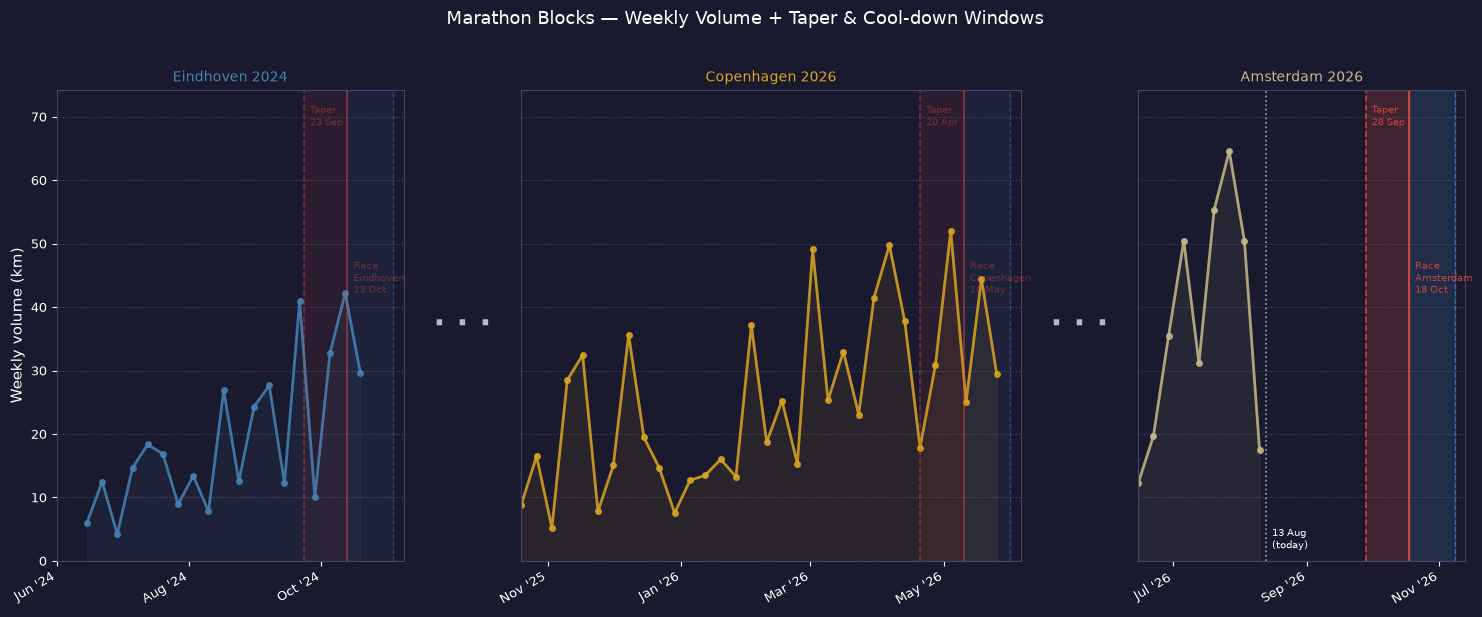

Amsterdam Marathon:  18 Oct 2026
Taper starts:        28 Sep 2026  (20 days before race)
Cool-down ends:      08 Nov 2026  (3 weeks after race)
Days to taper:       46
Today:               13 Aug 2026


In [31]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import os

TAPER_DAYS     = 20
COOLDOWN_WEEKS = 3

RACE_DATES = {
    "Eindhoven 2024":  pd.Timestamp("2024-10-13"),
    "Copenhagen 2026": pd.Timestamp("2026-05-10"),
    "Amsterdam 2026":  pd.Timestamp("2026-10-18"),
}

block_starts = {
    "Eindhoven 2024":  pd.Timestamp("2024-06-01"),
    "Copenhagen 2026": pd.Timestamp("2025-10-20"),
    "Amsterdam 2026":  pd.Timestamp("2026-06-15"),
}

COLORS = {
    "Eindhoven 2024":  "steelblue",
    "Copenhagen 2026": "goldenrod",
    "Amsterdam 2026":  "#C8B98A",
}

BG = "#1A1A2E"
today = pd.Timestamp.today().normalize()

DEDUP_DATES = {RACE_DATES["Eindhoven 2024"].normalize()}

def dedup_on_dates(df, dedup_dates):
    day_col    = df["start_date"].dt.normalize()
    mask_dedup = day_col.isin(dedup_dates)
    keep_idx   = df[mask_dedup].groupby(day_col[mask_dedup])["distance"].idxmax()
    return pd.concat([df[~mask_dedup], df.loc[keep_idx]]).sort_values("start_date")

# Pre-collect weekly data for all blocks
blocks_plot = {}
all_weekly_km = []
for name, start in block_starts.items():
    race         = RACE_DATES[name]
    cooldown_end = race + pd.Timedelta(weeks=COOLDOWN_WEEKS)
    plot_end     = min(cooldown_end, today + pd.Timedelta(days=1))
    b = dedup_on_dates(
        runs_ml[(runs_ml["start_date"] >= start) & (runs_ml["start_date"] < plot_end)].copy(),
        DEDUP_DATES
    )
    b["week"]   = (b["start_date"] - start).dt.days // 7
    wk          = b.groupby("week")["distance"].sum()
    week_dates  = [start + pd.Timedelta(weeks=int(w)) for w in wk.index]
    blocks_plot[name] = (week_dates, wk.values)
    all_weekly_km.extend(wk.values)

y_top = max(all_weekly_km) * 1.15 if all_weekly_km else 100

# Subplot widths proportional to each block's calendar span
widths = [(RACE_DATES[n] + pd.Timedelta(weeks=COOLDOWN_WEEKS) - s).days
          for n, s in block_starts.items()]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 6), facecolor=BG,
    gridspec_kw={"width_ratios": widths},
    sharey=True,
)
fig.patch.set_facecolor(BG)

for ax, (name, start) in zip(axes, block_starts.items()):
    race         = RACE_DATES[name]
    taper_start  = race - pd.Timedelta(days=TAPER_DAYS)
    cooldown_end = race + pd.Timedelta(weeks=COOLDOWN_WEEKS)
    is_upcoming  = race >= today
    t_alpha  = 0.18 if is_upcoming else 0.08
    cd_alpha = 0.14 if is_upcoming else 0.06
    l_alpha  = 0.8  if is_upcoming else 0.4

    ax.set_facecolor(BG)
    ax.tick_params(colors="white", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")
    ax.grid(axis="y", alpha=0.2, linestyle=":")

    week_dates, wk_vals = blocks_plot[name]
    ax.plot(week_dates, wk_vals, color=COLORS[name], linewidth=2,
            marker="o", markersize=4, alpha=0.85)
    ax.fill_between(week_dates, 0, wk_vals, color=COLORS[name], alpha=0.08)

    ax.axvspan(taper_start, race, color="#E74C3C", alpha=t_alpha, zorder=0)
    ax.axvline(taper_start, color="#E74C3C", linewidth=1.2, linestyle="--", alpha=l_alpha)
    ax.text(taper_start, y_top * 0.97, f"  Taper\n  {taper_start.strftime('%d %b')}",
            color="#E74C3C", fontsize=7.5, va="top", alpha=l_alpha)

    ax.axvline(race, color="#E74C3C", linewidth=1.5, linestyle="-", alpha=l_alpha)
    ax.text(race, y_top * 0.60, f"  Race\n  {name.split()[0]}\n  {race.strftime('%d %b')}",
            color="#E74C3C", fontsize=7, va="center", alpha=l_alpha)

    ax.axvspan(race, cooldown_end, color="#4E9AF1", alpha=cd_alpha, zorder=0)
    ax.axvline(cooldown_end, color="#4E9AF1", linewidth=1, linestyle="--", alpha=l_alpha * 0.7)

    if name == "Amsterdam 2026" and today <= cooldown_end:
        ax.axvline(today, color="white", linewidth=1.2, linestyle=":", alpha=0.6)
        ax.text(today, y_top * 0.02, f"  {today.strftime('%d %b')}\n  (today)",
                color="white", fontsize=7, va="bottom")

    ax.set_xlim(start, cooldown_end + pd.Timedelta(days=5))
    ax.set_ylim(0, y_top)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", color="white")
    ax.set_title(name, color=COLORS[name], fontsize=10, pad=6)

    if ax is not axes[0]:
        ax.tick_params(axis="y", left=False, labelleft=False)

axes[0].set_ylabel("Weekly volume (km)", color="white", fontsize=11)
fig.suptitle("Marathon Blocks — Weekly Volume + Taper & Cool-down Windows",
             color="white", fontsize=13, y=1.02)

# tight_layout first, then widen the inter-panel gaps so the "···" has room
plt.tight_layout()
fig.subplots_adjust(wspace=0.30)
fig.canvas.draw()

for i in range(2):
    x_mid = (axes[i].get_position().x1 + axes[i + 1].get_position().x0) / 2
    y_mid = (axes[0].get_position().y0  + axes[0].get_position().y1)  / 2
    fig.text(x_mid, y_mid, "· · ·", color="white", fontsize=22,
             ha="center", va="center", fontweight="bold", alpha=0.7)

plt.savefig(f"{os.getenv('FIGURES_DIR')}/4_taper_detection.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

amsterdam_race     = RACE_DATES["Amsterdam 2026"]
amsterdam_taper    = amsterdam_race - pd.Timedelta(days=TAPER_DAYS)
amsterdam_cooldown = amsterdam_race + pd.Timedelta(weeks=COOLDOWN_WEEKS)
days_to_taper      = (amsterdam_taper - today).days
print(f"Amsterdam Marathon:  {amsterdam_race.strftime('%d %b %Y')}")
print(f"Taper starts:        {amsterdam_taper.strftime('%d %b %Y')}  ({TAPER_DAYS} days before race)")
print(f"Cool-down ends:      {amsterdam_cooldown.strftime('%d %b %Y')}  ({COOLDOWN_WEEKS} weeks after race)")
if days_to_taper > 0:
    print(f"Days to taper:       {days_to_taper}")
else:
    print(f"Taper already started {abs(days_to_taper)} days ago")
print(f"Today:               {today.strftime('%d %b %Y')}")

## 5. Volume Forecast — Amsterdam 2026 (Holt's Exponential Smoothing)
Extrapolates the weekly volume trajectory from the last observed week using **Holt's double exponential smoothing with damping**. The model captures both the current level and the recent upward trend, while the damping parameter prevents the forecast from growing unrealistically far into the future. The taper weeks (3–1 before race day) are post-processed with fixed percentage reductions: 80 % → 60 % → 40 %.

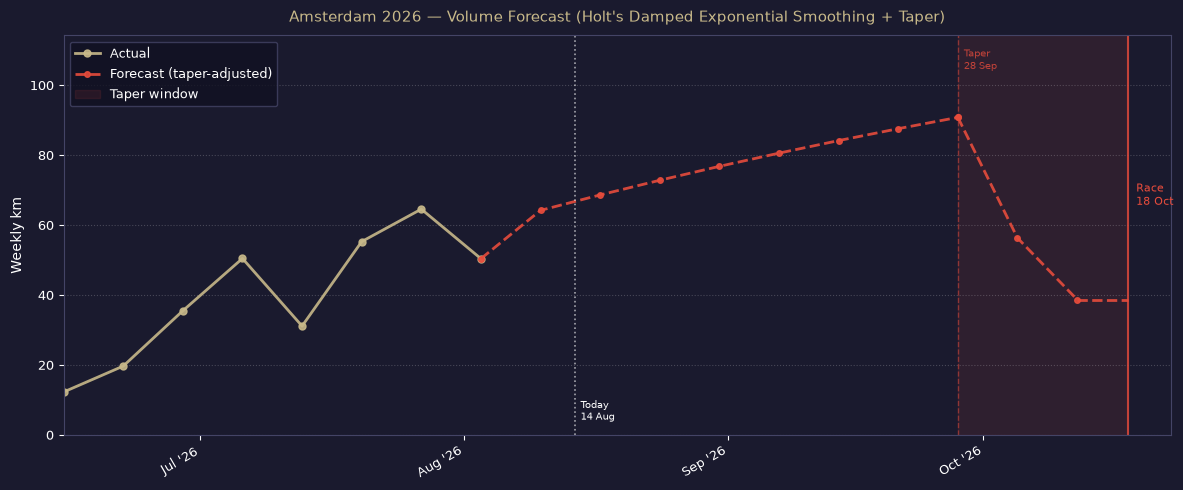

α  level smoothing : 0.000
β  trend smoothing : 0.000
φ  damping factor  : 0.949

Taper starts       : 28 Sep 2026
Forecast horizon   : 10 weeks  (up to race day)
Peak raw forecast  : 96.8 km/week
Total forecast km  : 703 km  (incl. taper)


In [42]:
from statsmodels.tsa.holtwinters import Holt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

BG    = "#1A1A2E"
CREAM = "#C8B98A"
today = pd.Timestamp.today().normalize()

# ── Amsterdam training data (up to & including 9 Aug) ─────────────────────────
ams_start = pd.Timestamp("2026-06-15")
race_ams  = pd.Timestamp("2026-10-18")
cutoff    = pd.Timestamp("2026-08-10")  # exclusive upper bound

mask = (runs_ml["start_date"] >= ams_start) & (runs_ml["start_date"] < cutoff)
b = runs_ml[mask].copy()
b["week_num"] = (b["start_date"] - ams_start).dt.days // 7
wk = b.groupby("week_num")["distance"].sum().reset_index(name="km")
wk["ds"] = ams_start + pd.to_timedelta(wk["week_num"] * 7, unit="D")

# ── Fit Holt's damped-trend model ─────────────────────────────────────────────
model  = Holt(wk["km"].values, damped_trend=True)
fitted = model.fit(optimized=True)

# ── Forecast from last actual week up to (not past) race day ──────────────────
last_ds  = wk["ds"].max()
last_val = wk["km"].iloc[-1]
h        = int((race_ams - last_ds).days / 7)

fc_raw = fitted.forecast(h)
fc_ds  = [last_ds + pd.Timedelta(weeks=i + 1) for i in range(h)]

# ── Taper post-processing ─────────────────────────────────────────────────────
TAPER_FACTORS = {3: 0.80, 2: 0.60, 1: 0.40}
fc_adj = np.array([
    max(0.0, v * TAPER_FACTORS.get(round((race_ams - d).days / 7), 1.0))
    for d, v in zip(fc_ds, fc_raw)
])

# Shading boundary = first dot that actually gets reduced
taper_idx   = next(i for i, d in enumerate(fc_ds)
                   if TAPER_FACTORS.get(round((race_ams - d).days / 7), 1.0) < 1.0)
taper_start = fc_ds[taper_idx]

# Full plot arrays (prepend last actual so lines connect)
plot_ds  = [last_ds] + fc_ds
plot_raw = np.concatenate([[last_val], fc_raw])
plot_adj = np.concatenate([[last_val], fc_adj])

# ── Plot ──────────────────────────────────────────────────────────────────────
y_ceil = max(wk["km"].max(), fc_raw.max()) * 1.18

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(BG)
ax.tick_params(colors="white", labelsize=9)
for spine in ax.spines.values():
    spine.set_edgecolor("#444466")

ax.plot(wk["ds"], wk["km"],
        color=CREAM, linewidth=2, marker="o", markersize=5,
        label="Actual", alpha=0.9)


# ── Red forecast: climb → peak dot at axvline → descent ───────────────────────
# gap is the index in plot_* of the first taper point (= taper_start date)
gap = taper_idx + 1

# Segment 1: climb using raw values, ending with a peak dot exactly at taper_start
xs1 = plot_ds[:gap + 1]                                          # last_ds … taper_start
ys1 = np.concatenate([plot_adj[:gap], [fc_raw[taper_idx]]])     # raw at boundary = peak
ax.plot(xs1, ys1,
        color="#E74C3C", linewidth=2, linestyle="--", marker="o", markersize=4,
        label="Forecast (taper-adjusted)", alpha=0.9)

# Segment 2: descent from peak dot through taper weeks, flat to race day
xs2 = [taper_start] + plot_ds[gap + 1:]                         # taper_start, Oct 5, Oct 12
ys2 = [fc_raw[taper_idx]] + list(plot_adj[gap + 1:])            # peak, 0.60×, 0.40×
ax.plot(xs2, ys2,
        color="#E74C3C", linewidth=2, linestyle="--", marker="o", markersize=4, alpha=0.9)

# Flat extension from last taper dot to race day (no marker)
ax.plot([plot_ds[-1], race_ams], [plot_adj[-1], plot_adj[-1]],
        color="#E74C3C", linewidth=2, linestyle="--", alpha=0.9)

ax.axvspan(taper_start, race_ams,
           color="#E74C3C", alpha=0.10, zorder=0, label="Taper window")
ax.axvline(taper_start, color="#E74C3C", linewidth=1, linestyle="--", alpha=0.5)
ax.text(taper_start, y_ceil * 0.97,
        f"  Taper\n  {taper_start.strftime('%d %b')}",
        color="#E74C3C", fontsize=7.5, va="top", alpha=0.8)
ax.axvline(race_ams, color="#E74C3C", linewidth=1.5, linestyle="-", alpha=0.8)
ax.text(race_ams, y_ceil * 0.60,
        f"  Race\n  {race_ams.strftime('%d %b')}", color="#E74C3C", fontsize=8, va="center")

ax.axvline(today, color="white", linewidth=1.2, linestyle=":", alpha=0.6)
ax.text(today, y_ceil * 0.03,
        f"  Today\n  {today.strftime('%d %b')}", color="white", fontsize=7, va="bottom")

ax.set_xlim(ams_start, race_ams + pd.Timedelta(days=5))
ax.set_ylim(0, y_ceil)
ax.set_ylabel("Weekly km", color="white", fontsize=10)
ax.grid(axis="y", alpha=0.2, linestyle=":")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", color="white")
ax.legend(facecolor="#111122", edgecolor="#444466", labelcolor="white", fontsize=9,
          loc="upper left")
ax.set_title("Amsterdam 2026 — Volume Forecast (Holt's Damped Exponential Smoothing + Taper)",
             color=CREAM, fontsize=11, pad=10)

plt.tight_layout()
plt.savefig(f"{os.getenv('FIGURES_DIR')}/5_volume_forecast_holt.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
p = fitted.params
print(f"α  level smoothing : {p['smoothing_level']:.3f}")
print(f"β  trend smoothing : {p['smoothing_trend']:.3f}")
print(f"φ  damping factor  : {p['damping_trend']:.3f}")
print(f"\nTaper starts       : {taper_start.strftime('%d %b %Y')}")
print(f"Forecast horizon   : {h} weeks  (up to race day)")
print(f"Peak raw forecast  : {fc_raw.max():.1f} km/week")
print(f"Total forecast km  : {fc_adj.sum():.0f} km  (incl. taper)")
